# Overall Setup

importing of dataset from Kaggle

In [25]:
import kagglehub
import pandas as pd
import os


# Download latest version of the dataset from Kaggle
path = kagglehub.dataset_download("yagizfiratt/nba-players-database")

# List the files in directory, use file name obtained below to create DataFrame
print(os.listdir(path))

bball_df = pd.read_csv(path + '/PlayerIndex_nba_stats.csv')

['PlayerIndex_nba_stats.csv']


Exploring the data

In [26]:
# Get a sense of the useful columns to be used as features
print(bball_df.columns)

print('\n')

print(bball_df.head())

print('\n')

# Columns to be used as features in predictions
# Checking for nulls to be cleaned up in pre-processing
print(bball_df[['PTS','REB','AST', 'HEIGHT', 'WEIGHT','POSITION']].info())

Index(['PERSON_ID', 'PLAYER_LAST_NAME', 'PLAYER_FIRST_NAME', 'PLAYER_SLUG',
       'TEAM_ID', 'TEAM_SLUG', 'IS_DEFUNCT', 'TEAM_CITY', 'TEAM_NAME',
       'TEAM_ABBREVIATION', 'JERSEY_NUMBER', 'POSITION', 'HEIGHT', 'WEIGHT',
       'COLLEGE', 'COUNTRY', 'DRAFT_YEAR', 'DRAFT_ROUND', 'DRAFT_NUMBER',
       'ROSTER_STATUS', 'PTS', 'REB', 'AST', 'STATS_TIMEFRAME', 'FROM_YEAR',
       'TO_YEAR'],
      dtype='object')


   PERSON_ID PLAYER_LAST_NAME PLAYER_FIRST_NAME          PLAYER_SLUG  \
0      76001        Abdelnaby              Alaa       alaa-abdelnaby   
1      76002       Abdul-Aziz              Zaid      zaid-abdul-aziz   
2      76003     Abdul-Jabbar            Kareem  kareem-abdul-jabbar   
3         51       Abdul-Rauf           Mahmoud   mahmoud-abdul-rauf   
4       1505      Abdul-Wahad             Tariq    tariq-abdul-wahad   

      TEAM_ID TEAM_SLUG  IS_DEFUNCT    TEAM_CITY      TEAM_NAME  \
0  1610612757   blazers           0     Portland  Trail Blazers   
1  1610612745  

# Pre-Processing and Cleaning of Data



*   Assigning arbitrary values for points, rebounds and assist iterations that are null
*   Overwriting mixed positions so they are all pure; either Guard, Forward or Center
*   Dropping rows where height, weight or position are not filled (no way to correctly assign value without considering interdependencies)
*   Converting height from a string showing feet and inches to an integer showing total inches only





In [27]:
import numpy as np

# From a quick analysis, it was identified that all players with missing stats were of low significance and so a
# decision was made to assign a stat between zero and the average of the whole dataset
bball_df.loc[bball_df['REB'].isna(), 'REB'] = np.random.randint(0, 301, size=bball_df['REB'].isna().sum()) / 100.0
bball_df.loc[bball_df['PTS'].isna(), 'PTS'] = np.random.randint(0, 701, size=bball_df['PTS'].isna().sum()) / 100.0
bball_df.loc[bball_df['AST'].isna(), 'AST'] = np.random.randint(0, 201, size=bball_df['AST'].isna().sum()) / 100.0

bball_df.loc[bball_df['POSITION']=='C-F', 'POSITION'] = 'C'
bball_df.loc[bball_df['POSITION']=='F-C', 'POSITION'] = 'F'
bball_df.loc[bball_df['POSITION']=='G-F', 'POSITION'] = 'G'
bball_df.loc[bball_df['POSITION']=='F-G', 'POSITION'] = 'F'

bball_df.dropna(subset=['HEIGHT'], inplace=True)
bball_df.dropna(subset=['WEIGHT'], inplace=True)
bball_df.dropna(subset=['POSITION'], inplace=True)

# Creating a function to convert strings to int & feet to inches
def convert_height(height):
  return int(height.split('-')[0])*12 + int(height.split('-')[1])

bball_df['NEW_HEIGHT'] = bball_df['HEIGHT'].apply(convert_height)

#Ensuring data looks clean before continuing
print(bball_df[['PTS','REB','AST', 'HEIGHT', 'WEIGHT','POSITION']].info())

<class 'pandas.core.frame.DataFrame'>
Index: 4970 entries, 0 to 5024
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   PTS       4970 non-null   float64
 1   REB       4970 non-null   float64
 2   AST       4970 non-null   float64
 3   HEIGHT    4970 non-null   object 
 4   WEIGHT    4970 non-null   float64
 5   POSITION  4970 non-null   object 
dtypes: float64(4), object(2)
memory usage: 271.8+ KB
None


Calculating the 90th percentile for all 3 statistical fields and creating a new dataframe containing only players who have at least one stat within this range (To be used in later predictions)

In [28]:
# Calculate the 90th percentile for relevant columns
percentiles_90 = bball_df[['PTS', 'REB', 'AST']].quantile(0.9)

# Filter the DataFrame to include players AT or ABOVE the 90th percentile for any major stat
players_90th_percentile_df = bball_df[
    (bball_df['PTS'] >= percentiles_90['PTS']) |
    (bball_df['REB'] >= percentiles_90['REB']) |
    (bball_df['AST'] >= percentiles_90['AST'])
].copy()

players_90th_percentile_df[['PTS','REB','AST']].describe()

,PTS,REB,AST
count,1045.000000,1045.000000,1045.000000
mean,12.994163,5.455244,3.188900
std,5.142712,2.835581,1.813025
min,2.000000,0.500000,0.000000
25%,9.000000,3.000000,1.700000
50%,12.600000,5.300000,3.000000
75%,16.200000,7.200000,4.200000
max,32.700000,22.900000,11.600000


#Observations



Printing out a simple plot of all the teams in the dataframe and comparing how many players (at each position) each has ever had.

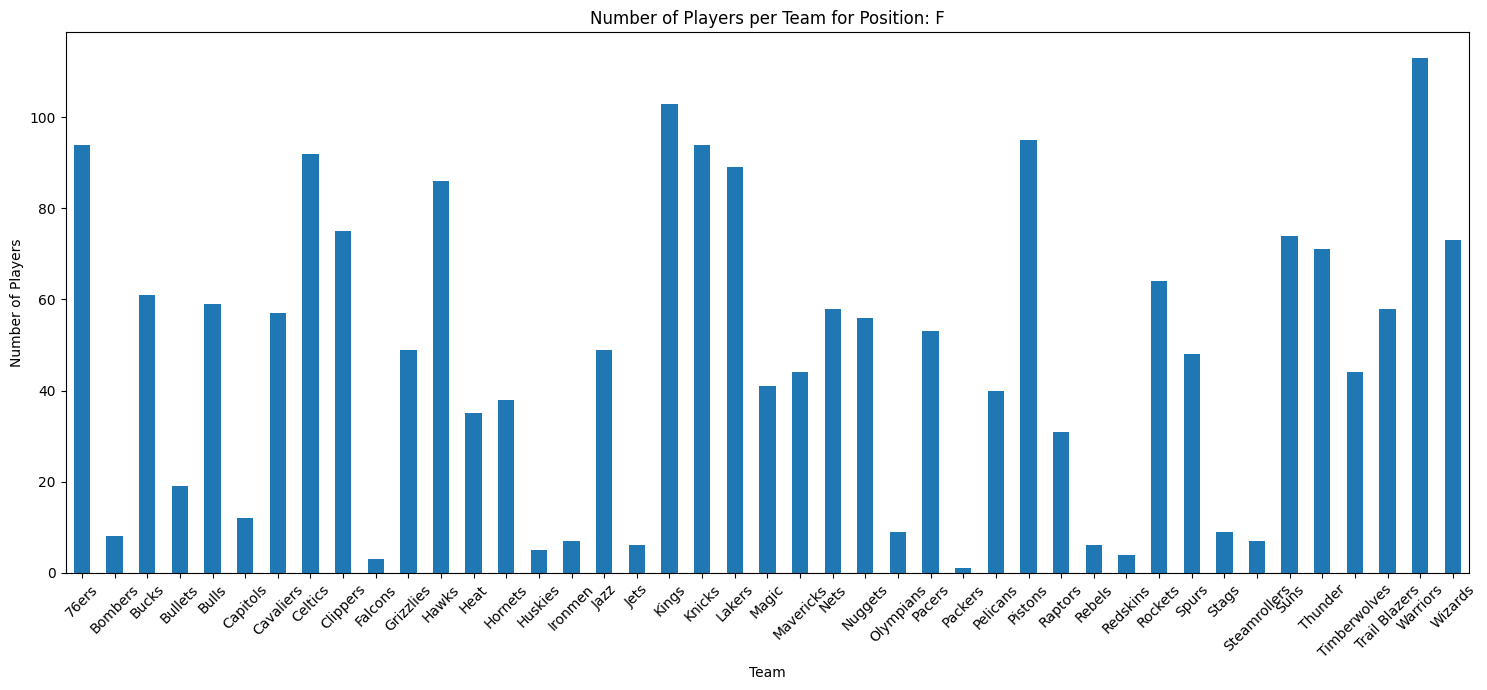

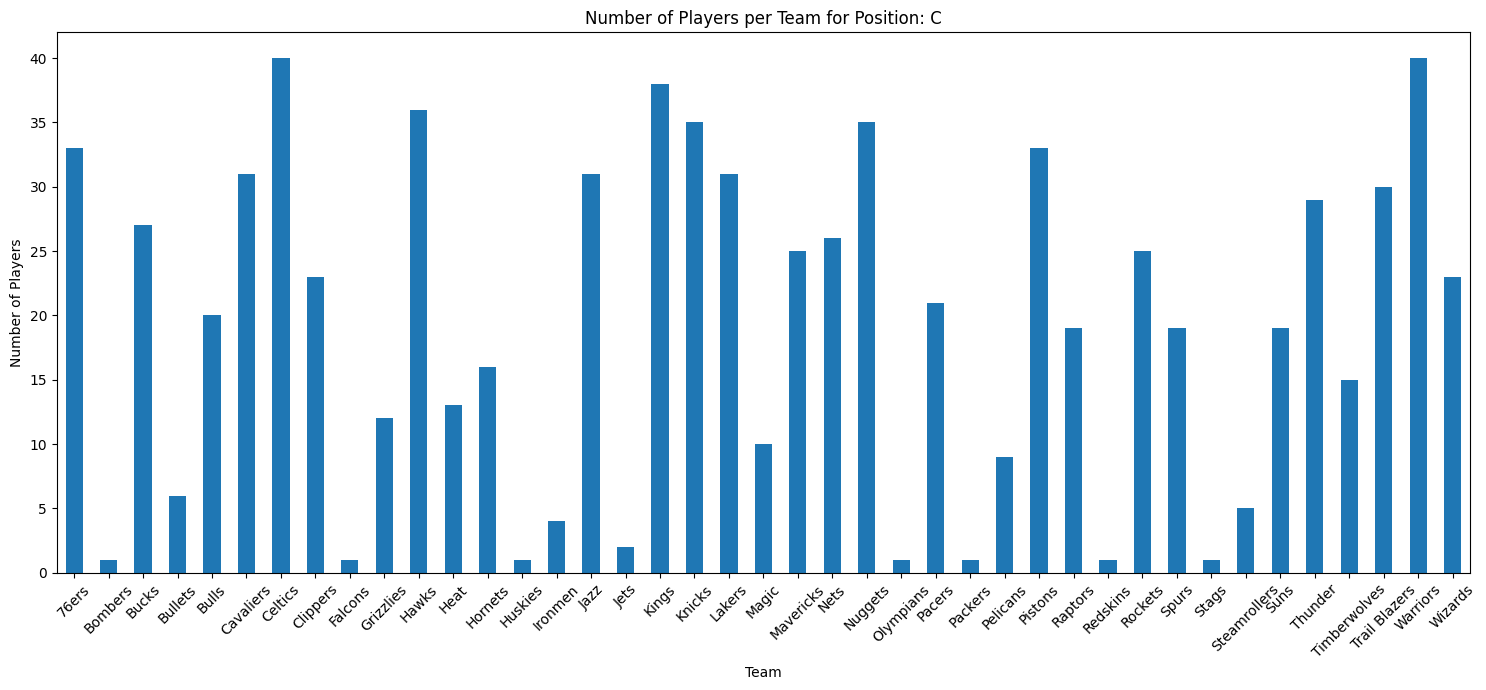

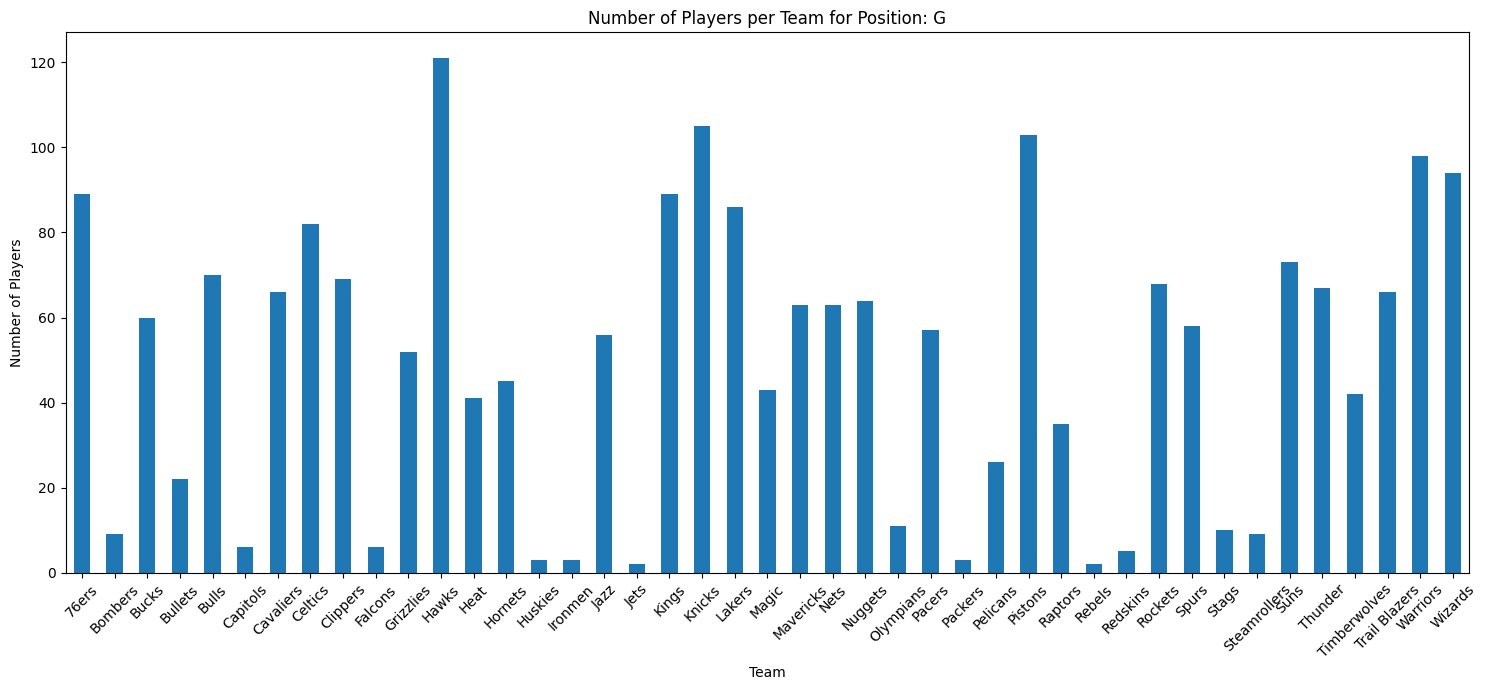

In [29]:
import matplotlib.pyplot as plt

positions = bball_df['POSITION'].unique()

# Printing a plot for each position
for position in positions:

    position_df = bball_df[bball_df['POSITION'] == position]

    # Group by team and obtaining a count
    team_counts = position_df.groupby('TEAM_NAME')['PERSON_ID'].count()

    plt.figure(figsize=(15, 7)) # Adjust figure size for readability
    team_counts.plot(kind='bar')
    plt.title(f'Number of Players per Team for Position: {position}')
    plt.xlabel('Team')
    plt.ylabel('Number of Players')
    plt.xticks(rotation=45) # Rotate x-axis labels for better visibility
    plt.tight_layout() # Adjust layout to prevent labels from overlapping
    plt.show()

Sidebar: many of the teams listed above were completely new to me and so I wanted to print these out as well as the city they originated in.

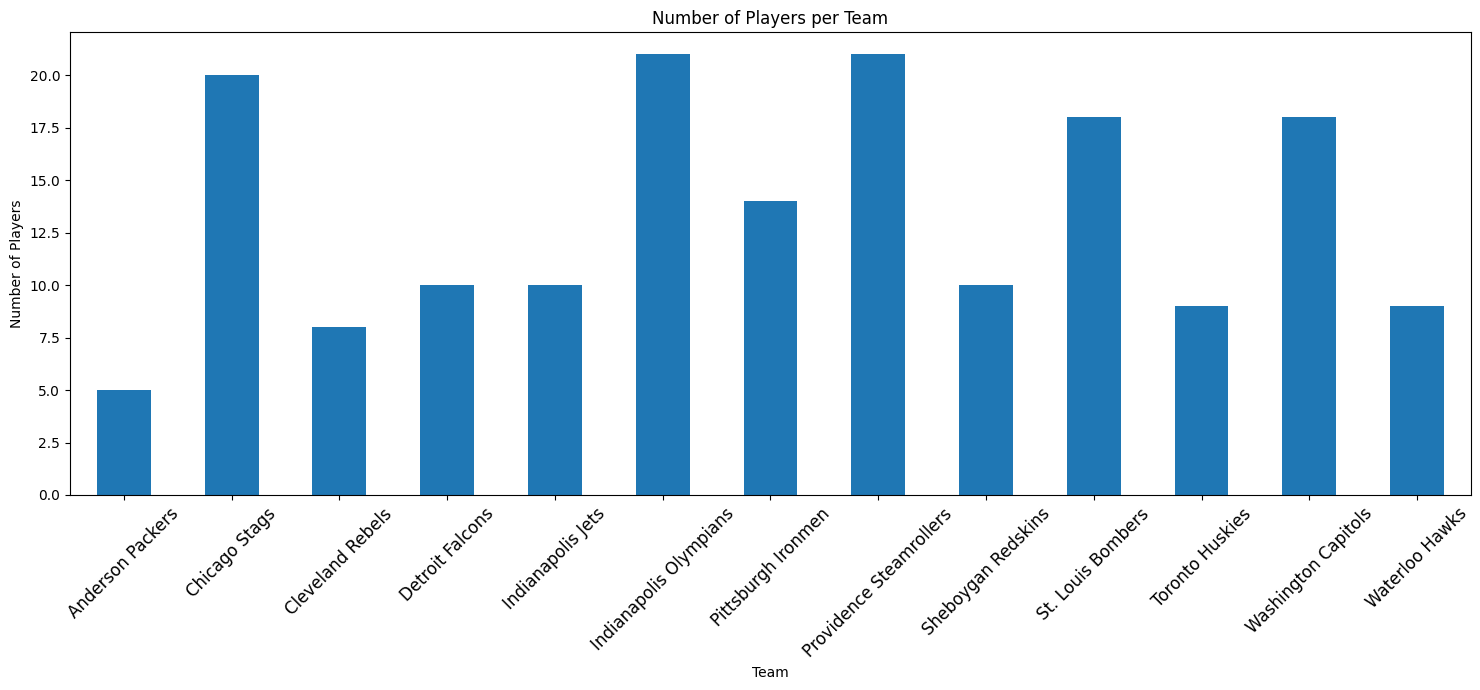

In [30]:
# Adding the city to the team name
bball_df['Full_team_name'] = bball_df['TEAM_CITY'] + ' '+ bball_df['TEAM_NAME']

# Calculate the count of players per team
team_counts = bball_df.groupby(['Full_team_name'])['PERSON_ID'].count()

# Filter for the smallest teams
minor_teams_df = team_counts[team_counts < 40]

plt.figure(figsize=(15, 7))
minor_teams_df.plot(kind='bar')
plt.title('Number of Players per Team')
plt.xlabel('Team')
plt.ylabel('Number of Players')
plt.xticks(rotation=45, fontsize=12)
plt.tight_layout()
plt.show()

Next I wished to calculate the best average stats (per position) in each NBA era (or decade in this case).


[1940. 1950. 1960. 1970. 1980. 1990. 2000. 2010. 2020.]


<Figure size 1500x700 with 0 Axes>

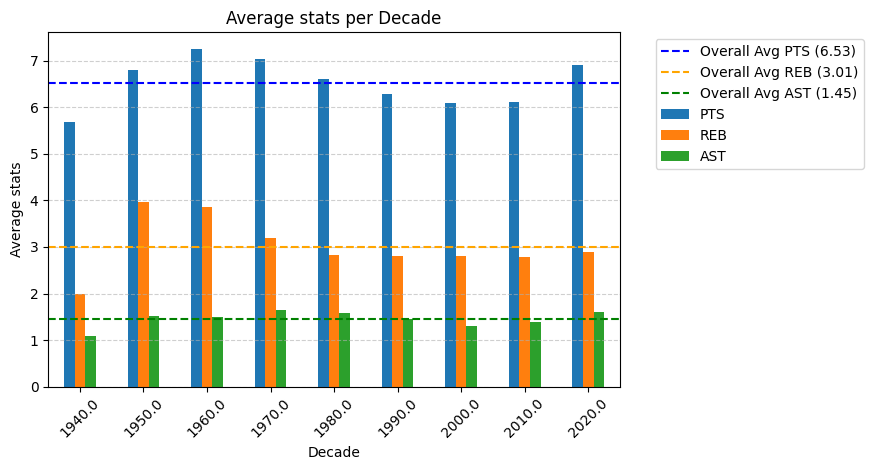

In [31]:
# Take the middle year for players who are retired (likely to be their prime year)
bball_df['Avg_Year'] = (bball_df['FROM_YEAR'] + bball_df['TO_YEAR']) / 2

Avg_stats_per_year = bball_df.groupby('Avg_Year')[['PTS', 'REB', 'AST']].mean()

# Add 'Decade' into the dataframe by taking the floor of the year divided by 10 and multiplying by 10
Avg_stats_per_year['Decade'] = (Avg_stats_per_year.index // 10) * 10

# Group by the new 'Decade' column and calculate the mean for each decade
Avg_stats_per_decade = Avg_stats_per_year.groupby('Decade')[['PTS', 'REB', 'AST']].mean()

# Print result to ensure correct calculations
print(Avg_stats_per_year['Decade'].unique())

plt.figure(figsize=(15, 7))
Avg_stats_per_decade.plot(kind='bar')
plt.title('Average stats per Decade')
plt.xlabel('Decade')
plt.ylabel('Average stats')
plt.xticks(rotation=45)
plt.tight_layout()

# Calculate the overall average for each metric across all decades
overall_avg_pts = Avg_stats_per_decade['PTS'].mean()
overall_avg_reb = Avg_stats_per_decade['REB'].mean()
overall_avg_ast = Avg_stats_per_decade['AST'].mean()

# Use axhline to add in the means for each stat into the graph
plt.axhline(overall_avg_pts, color='blue', linestyle='--', label=f'Overall Avg PTS ({overall_avg_pts:.2f})')
plt.axhline(overall_avg_reb, color='orange', linestyle='--', label=f'Overall Avg REB ({overall_avg_reb:.2f})')
plt.axhline(overall_avg_ast, color='green', linestyle='--', label=f'Overall Avg AST ({overall_avg_ast:.2f})')

# Adding grid lines for clarity
plt.grid(axis='y', linestyle='--', alpha=0.6)

# Adding a legend and moving it out of the plot for better visibility
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.show()

Same exercise as above but completed for each individual position.

<Figure size 1500x700 with 0 Axes>

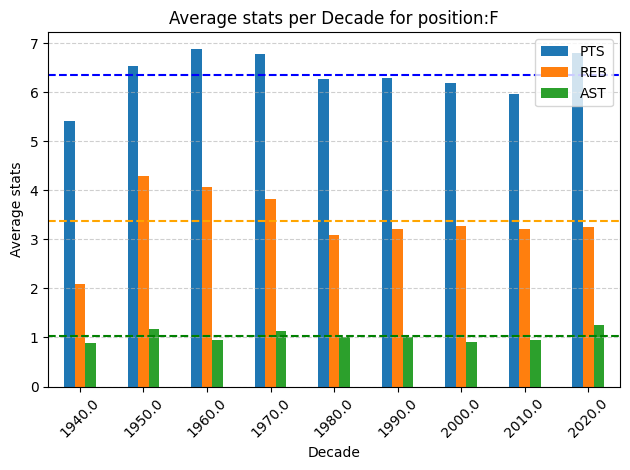

<Figure size 1500x700 with 0 Axes>

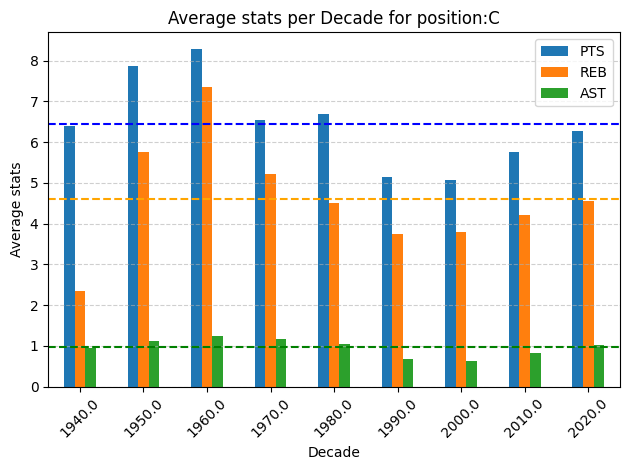

<Figure size 1500x700 with 0 Axes>

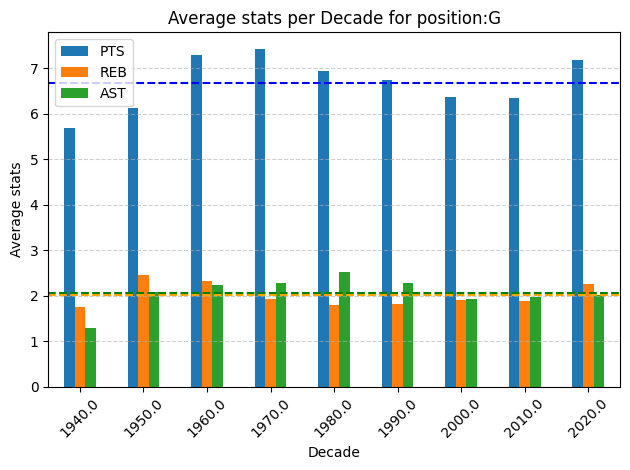

In [32]:
# filtering through the positions (list created above)
for position in positions:
  position_df = bball_df[bball_df['POSITION'] == position].copy()
  position_df['Avg_Year'] = (position_df['FROM_YEAR'] + position_df['TO_YEAR']) / 2
  Avg_stats_per_year = position_df.groupby('Avg_Year')[['PTS', 'REB', 'AST']].mean()
  Avg_stats_per_year['Decade'] = (Avg_stats_per_year.index // 10) * 10
  Avg_stats_per_decade = Avg_stats_per_year.groupby('Decade')[['PTS', 'REB', 'AST']].mean()

  plt.figure(figsize=(15, 7))
  Avg_stats_per_decade.plot(kind='bar')
  plt.title('Average stats per Decade for position:' + position)
  plt.xlabel('Decade')
  plt.ylabel('Average stats')
  plt.xticks(rotation=45)
  plt.tight_layout()

  # Calculate the overall average for each metric across all decades
  overall_avg_pts = Avg_stats_per_decade['PTS'].mean()
  overall_avg_reb = Avg_stats_per_decade['REB'].mean()
  overall_avg_ast = Avg_stats_per_decade['AST'].mean()

  # Use axhline to add in the means for each stat into the graph
  plt.axhline(overall_avg_pts, color='blue', linestyle='--', label=f'Overall Avg PTS ({overall_avg_pts:.2f})')
  plt.axhline(overall_avg_reb, color='orange', linestyle='--', label=f'Overall Avg REB ({overall_avg_reb:.2f})')
  plt.axhline(overall_avg_ast, color='green', linestyle='--', label=f'Overall Avg AST ({overall_avg_ast:.2f})')

  plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.show()

Same graphs as above but this time, only looking at the the players with a major stat in the 90th percentile.

<Figure size 1500x700 with 0 Axes>

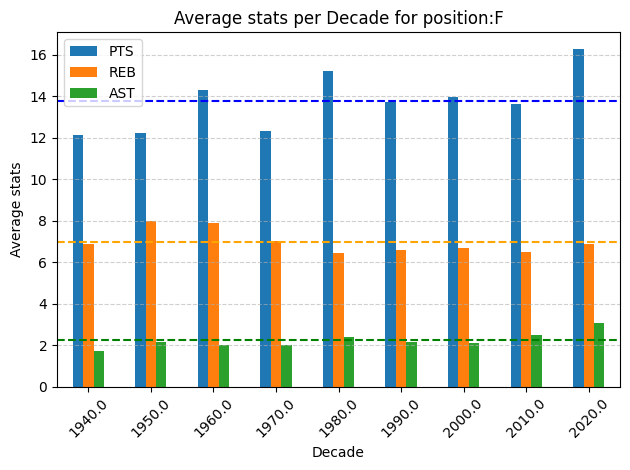

<Figure size 1500x700 with 0 Axes>

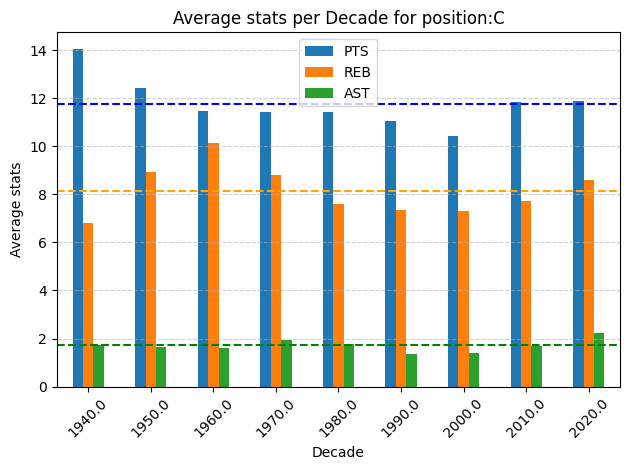

<Figure size 1500x700 with 0 Axes>

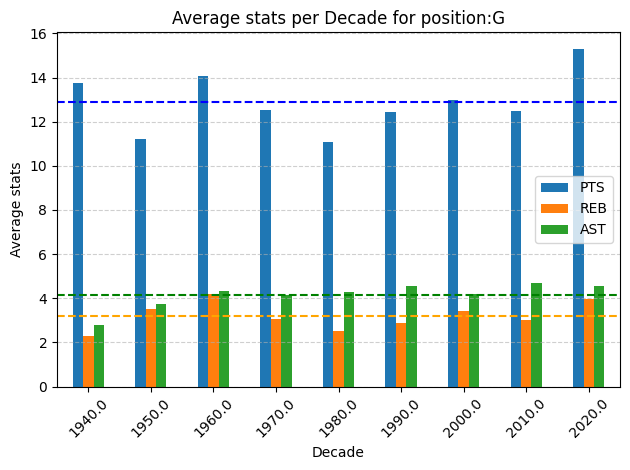

In [33]:
# filtering through the positions (list created above)
for position in positions:
  position_df = players_90th_percentile_df[players_90th_percentile_df['POSITION'] == position].copy()
  position_df['Avg_Year'] = (position_df['FROM_YEAR'] + position_df['TO_YEAR']) / 2
  Avg_stats_per_year = position_df.groupby('Avg_Year')[['PTS', 'REB', 'AST']].mean()
  Avg_stats_per_year['Decade'] = (Avg_stats_per_year.index // 10) * 10
  Avg_stats_per_decade = Avg_stats_per_year.groupby('Decade')[['PTS', 'REB', 'AST']].mean()

  plt.figure(figsize=(15, 7))
  Avg_stats_per_decade.plot(kind='bar')
  plt.title('Average stats per Decade for position:' + position)
  plt.xlabel('Decade')
  plt.ylabel('Average stats')
  plt.xticks(rotation=45)
  plt.tight_layout()

  # Calculate the overall average for each metric across all decades
  overall_avg_pts = Avg_stats_per_decade['PTS'].mean()
  overall_avg_reb = Avg_stats_per_decade['REB'].mean()
  overall_avg_ast = Avg_stats_per_decade['AST'].mean()

  # Use axhline to add in the means for each stat into the graph
  plt.axhline(overall_avg_pts, color='blue', linestyle='--', label=f'Overall Avg PTS ({overall_avg_pts:.2f})')
  plt.axhline(overall_avg_reb, color='orange', linestyle='--', label=f'Overall Avg REB ({overall_avg_reb:.2f})')
  plt.axhline(overall_avg_ast, color='green', linestyle='--', label=f'Overall Avg AST ({overall_avg_ast:.2f})')

  plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.show()

In [34]:
# Investigating centers contributing to high points in 90th percentile group
players_90th_percentile_df[(players_90th_percentile_df['FROM_YEAR']<1955) & (players_90th_percentile_df['POSITION']=='C')].sort_values(by='PTS', ascending=False)[['PLAYER_SLUG','TEAM_NAME','POSITION','PTS','REB']]

,PLAYER_SLUG,TEAM_NAME,POSITION,PTS,REB
3022,george-mikan,Lakers,C,23.1,13.40
1711,alex-groza,Olympians,C,22.5,10.70
2283,neil-johnston,Warriors,C,19.4,11.30
2731,ed-macauley,Celtics,C,17.5,7.50
2701,clyde-lovellette,Lakers,C,17.0,9.50
3892,ed-sadowski,Warriors,C,15.6,2.91
2414,johnny-kerr,76ers,C,13.8,11.20
1426,larry-foust,Pistons,C,13.7,9.80
3758,arnie-risen,Kings,C,12.0,9.70
1349,ray-felix,Knicks,C,10.9,8.90


Decided to check which colleges had the most amount of players drafted in round 1 and round 2 of the draft (i.e. the most valuable players come from which college?)

Top 5 colleges with the most players drafted in Round 1:
          College  Player_Count_Round_1
0        Kentucky                    59
1            Duke                    56
2  North Carolina                    54
3            UCLA                    41
4          Kansas                    36




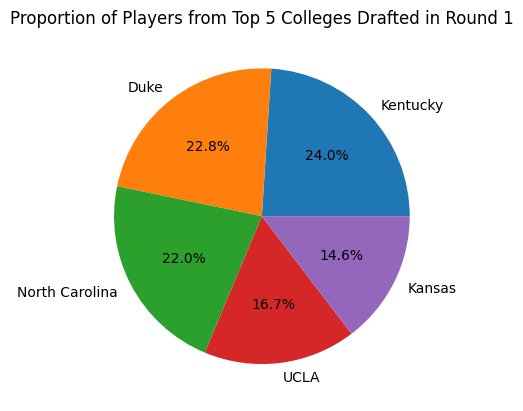



Top 5 colleges with the most players drafted in Round 2:
    College  Player_Count_Round_2
0      UCLA                    27
1   Arizona                    25
3   Indiana                    22
2  Kentucky                    22
5    Kansas                    20




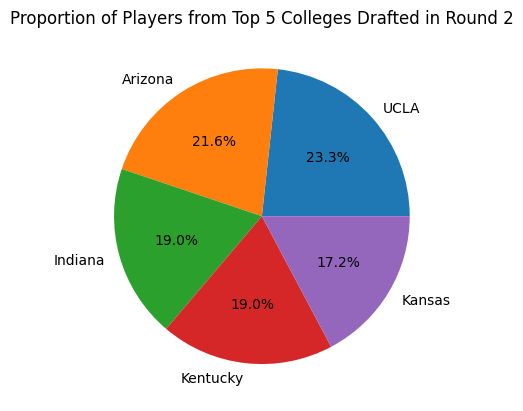

In [35]:
# Select the columns for Round 1 and Round 2
round_1_drafts = bball_df[bball_df['DRAFT_ROUND']==1].copy()
round_2_drafts = bball_df[bball_df['DRAFT_ROUND']==2].copy()

# Group by COLLEGE and count players for Round 1, then order them
college_counts_round_1 = round_1_drafts['COLLEGE'].value_counts().reset_index()
college_counts_round_1.columns = ['College', 'Player_Count_Round_1']
top_5_round_1 = college_counts_round_1.sort_values(by='Player_Count_Round_1', ascending=False).head(5)

# Same for players drafted in Round 2
college_counts_round_2 = round_2_drafts['COLLEGE'].value_counts().reset_index()
college_counts_round_2.columns = ['College', 'Player_Count_Round_2']
top_5_round_2 = college_counts_round_2.sort_values(by='Player_Count_Round_2', ascending=False).head(5)

print('Top 5 colleges with the most players drafted in Round 1:')
print(top_5_round_1)

print('\n')

# Creating a pie chart to illustrate both findings
plt.figure()
plt.pie(top_5_round_1['Player_Count_Round_1'], labels=top_5_round_1['College'], autopct='%1.1f%%')
plt.title('Proportion of Players from Top 5 Colleges Drafted in Round 1')
plt.show()

print('\n')

print('Top 5 colleges with the most players drafted in Round 2:')
print(top_5_round_2)

print('\n')

plt.figure()
plt.pie(top_5_round_2['Player_Count_Round_2'], labels=top_5_round_2['College'], autopct='%1.1f%%')
plt.title('Proportion of Players from Top 5 Colleges Drafted in Round 2')
plt.show()

# Predictions


The purpose of this project is to build a model that can predict player positions based on major stats and later, physical metrics.

The first attempt involved using only the 3 main stats. It was decided that instead of individual estimators, that an ensemble of classifiers would be used to predict the positions and an overall voting classifier would pick out the most popular answer.

In [36]:
# Import all required classes
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, VotingClassifier, GradientBoostingClassifier
from sklearn.pipeline import Pipeline

# Selecting features and target
features = ['PTS', 'REB', 'AST']
target = 'POSITION'

X = bball_df[features]
y = bball_df[target]

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Creating a pipeline which includes a scaler to scale the data, the voting classifier as well as the
# individual classifiers (defined with default hyperparameters except for random state for consistency)
lr = LogisticRegression(random_state=42)
rf = RandomForestClassifier(random_state=42)
svc = SVC(probability=True, random_state=42)
gb = gb_clf = GradientBoostingClassifier(random_state=42)

vc = VotingClassifier(estimators=[('lr', lr), ('rf', rf), ('svc', svc), ('gb', gb)], voting='soft')

# Create a pipeline
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('voting', vc)
])

# Training on dataset and predicting positions
pipeline.fit(X_train, y_train)
y_pred_test = pipeline.predict(X_test)

# Calculate and print Accuracy
accuracy_test = accuracy_score(y_test, y_pred_test)
print(f'Accuracy on Test Set: {accuracy_test:.4f}')

Accuracy on Test Set: 0.7233


A new approach was then used which involved the physical attributes of the players, namely the height (calculated above in pre-processing) and weight.

In [37]:
New_features = ['PTS', 'REB', 'AST','NEW_HEIGHT','WEIGHT']
New_X = bball_df[New_features]

X_train, X_test, y_train, y_test = train_test_split(New_X, y, test_size=0.2, random_state=42)

# Creating new estimators and pipeline
lr = LogisticRegression(random_state=42)
rf = RandomForestClassifier(random_state=42)
svc = SVC(probability=False, random_state=42)
gb = gb_clf = GradientBoostingClassifier(random_state=42)

# It was found that 'hard' voting yielded slightly more accurate answers
vc = VotingClassifier(estimators=[('lr', lr), ('rf', rf), ('svc', svc), ('gb', gb)], voting='hard')

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('voting', vc)
])

pipeline.fit(X_train, y_train)
y_pred_test = pipeline.predict(X_test)

accuracy_test = accuracy_score(y_test, y_pred_test)
print(f'Accuracy on Test Set: {accuracy_test:.4f}')

Accuracy on Test Set: 0.8219


Fitting a learning curve to see if there is any over or under fitting happening within our model.

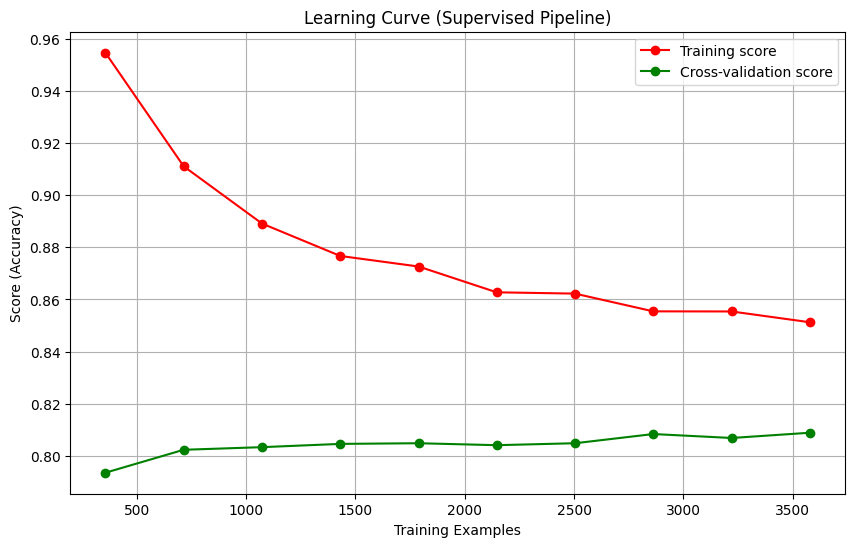

In [38]:
from sklearn.model_selection import learning_curve

# Creating learning curve with the best model and training data
train_sizes, train_scores, test_scores = learning_curve(
    pipeline, X_train, y_train, cv=10, scoring='accuracy', n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 10)) # Evaluate performance at 10 different training sizes

# Calculate mean and standard deviation for training and test scores
train_scores_mean = np.mean(train_scores, axis=1)
train_scores_std = np.std(train_scores, axis=1)
test_scores_mean = np.mean(test_scores, axis=1)
test_scores_std = np.std(test_scores, axis=1)

plt.figure(figsize=(10, 6))
plt.title("Learning Curve (Supervised Pipeline)")
plt.xlabel("Training Examples")
plt.ylabel("Score (Accuracy)")
plt.grid()

plt.plot(train_sizes, train_scores_mean, 'o-', color="r", label="Training score")
plt.plot(train_sizes, test_scores_mean, 'o-', color="g", label="Cross-validation score")

plt.legend()
plt.show()

Tuning the hyperparameters to attempt to solve the problem of overfitting spotted above.

In [39]:
# The boosting classifier was removed as it gave worse results as well as taking up a lot more time,
# Best parameters are below if interested to try it out
# Best parameters found (Randomized Search):  {'voting__gb__learning_rate': np.float64(0.04818220623006921), 'voting__gb__n_estimators': 116, 'voting__lr__C': np.float64(0.1794927466860925), 'voting__rf__max_depth': 35, 'voting__rf__n_estimators': 103, 'voting__svc__C': np.float64(0.706029796674973), 'voting__svc__gamma': 'auto'}
# Best Ensemble Model Accuracy on Test Set (Randomized Search): 0.8219315895372233

from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import uniform, randint

# The same X and y were used as before
X_train, X_test, y_train, y_test = train_test_split(New_X, y, test_size=0.2, random_state=42)

lr = LogisticRegression(random_state=42, max_iter=1000)
rf = RandomForestClassifier(random_state=42)
svc = SVC(probability=False, random_state=42)
#gb = gb_clf = GradientBoostingClassifier(random_state=42)

vc = VotingClassifier(estimators=[('lr', lr),
                                  ('rf', rf),
                                  ('svc', svc),
                                  #('gb', gb)
                                  ],voting='hard')

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('voting', vc)
])

# Define parameter distributions for RandomizedSearchCV
param_distributions = {
    'voting__lr__C': uniform(loc=0.01, scale=1), # Selecting randomly from a continuous distribution
    'voting__rf__n_estimators': randint(50, 200), # Selecting randomly from an integer distribution
    'voting__rf__max_depth': [35, 25],
    'voting__svc__C': uniform(loc=0.01, scale=1),
    'voting__svc__gamma': ['scale', 'auto'],
    #'voting__gb__n_estimators': randint(50, 200),
    #'voting__gb__learning_rate': uniform(loc=0.01, scale=0.2),
}

random_search = RandomizedSearchCV(pipeline, param_distributions, n_iter=50, cv=3, scoring='accuracy', random_state=42, n_jobs=-1)

random_search.fit(X_train, y_train)
print("Best parameters found (Randomized Search): ", random_search.best_params_)

best_model_random = random_search.best_estimator_
y_pred_random = best_model_random.predict(X_test)
accuracy_ensemble_random = accuracy_score(y_test, y_pred_random)
print(f'Best Ensemble Model Accuracy on Test Set (Randomized Search): {accuracy_ensemble_random}')

Best parameters found (Randomized Search):  {'voting__lr__C': np.float64(0.1031027678058992), 'voting__rf__max_depth': 25, 'voting__rf__n_estimators': 86, 'voting__svc__C': np.float64(0.8926363431893397), 'voting__svc__gamma': 'scale'}
Best Ensemble Model Accuracy on Test Set (Randomized Search): 0.8269617706237424


In [40]:
# Comparing train vs test accuracy for overfitting
y_pred_random_train = best_model_random.predict(X_train)
accuracy_ensemble_random_train = accuracy_score(y_train, y_pred_random_train)
print(f'Best Ensemble Model Accuracy on Train Set (Randomized Search): {accuracy_ensemble_random_train}')
print('\n')
y_pred_random = best_model_random.predict(X_test)
accuracy_ensemble_random = accuracy_score(y_test, y_pred_random)
print(f'Best Ensemble Model Accuracy on Test Set (Randomized Search): {accuracy_ensemble_random}')

Best Ensemble Model Accuracy on Train Set (Randomized Search): 0.829979879275654


Best Ensemble Model Accuracy on Test Set (Randomized Search): 0.8269617706237424


Printing out Confusion Matrix, F1 score and overall classification report for the best model.


Confusion Matrix:
[[ 93  44   1]
 [ 21 333  61]
 [  0  45 396]]


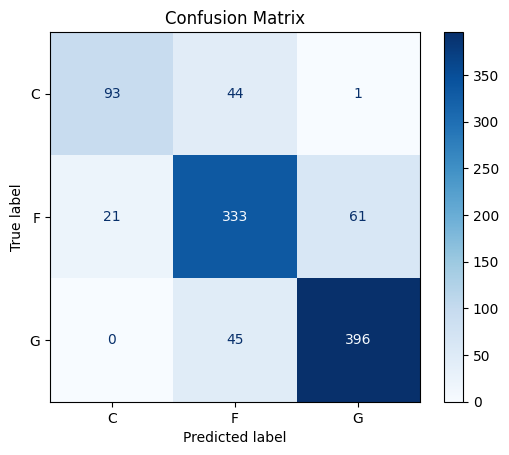



F1 Score (Weighted Average): 0.8255
F1 Score (Macro Average): 0.8049


Classification Report:
              precision    recall  f1-score   support

           C       0.75      0.72      0.74       138
           F       0.78      0.79      0.79       415
           G       0.88      0.88      0.88       441

    accuracy                           0.82       994
   macro avg       0.80      0.80      0.80       994
weighted avg       0.82      0.82      0.82       994



In [41]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, f1_score, classification_report

# Calculate the confusion matrix
cm = confusion_matrix(y_test, y_pred_random)
print("\nConfusion Matrix:")
print(cm)

# Creating a graph to better display confusion matrix
labels = sorted(y.unique())
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.show()
print('\n')

# Calculate the F1 score & printing out the classification report
f1_weighted = f1_score(y_test, y_pred_random, average='weighted')
f1_macro = f1_score(y_test, y_pred_random, average='macro')
print(f'F1 Score (Weighted Average): {f1_weighted:.4f}')
print(f'F1 Score (Macro Average): {f1_macro:.4f}')
print('\n')

report = classification_report(y_test, y_pred_test, target_names=labels)
print("Classification Report:")
print(report)

It was decided to take an unsupervised approach in order to evaluate whether it was possible for a machine to predict a players position based on stats without being given an answer to train from.

First step was obtaining an elbow plot to tell us how many clusters the model could confidently generate. In our case, we do want to have the same number of clusters as positions (3).

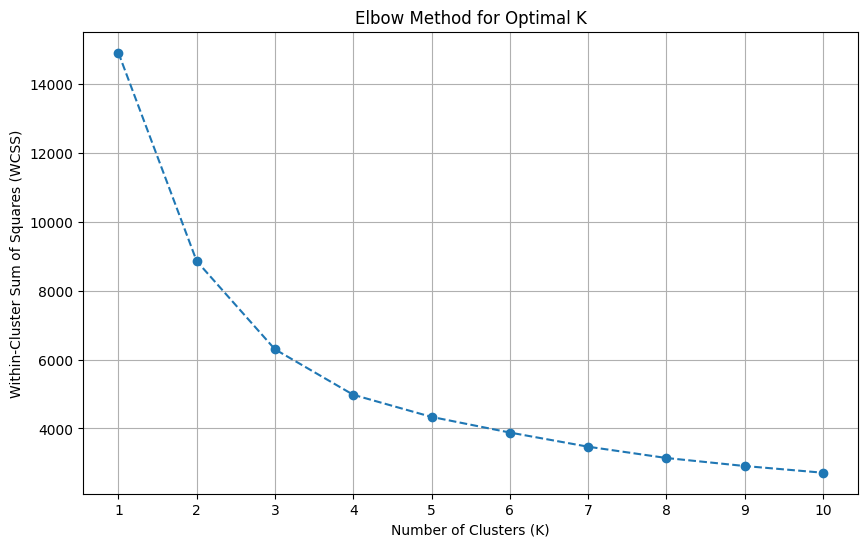

WCSS values for K = 1 to 10 : [14909.999999999982, 8858.916349322742, 6296.5713123969335, 4976.453176138987, 4333.559741588525, 3879.5729507720453, 3468.275470667817, 3140.259928757604, 2907.3411776381286, 2712.5877185454774]


In [42]:
from sklearn.cluster import KMeans

#Attempt at feature engineering
bball_df['HW_Ratio'] = bball_df['NEW_HEIGHT'] / bball_df['WEIGHT']

# Select the features used for the first unsupervised model (these would be changed manually to assess different models)
features_clustering = ['PTS', 'NEW_HEIGHT', 'WEIGHT']
X_clustering = bball_df[features_clustering]

scaler_clustering = StandardScaler()
X_scaled_clustering = scaler_clustering.fit_transform(X_clustering)

# Elbow method - list to store sum of squares
ss = []
# Define a range of K values to test
max_k = 10

# Calculate SS for different numbers of clusters
for i in range(1, max_k + 1):
    kmeans = KMeans(n_clusters=i, random_state=42, n_init=10)
    kmeans.fit(X_scaled_clustering)
    ss.append(kmeans.inertia_) # inertia_ is the SS

# Plot the Elbow Method graph
plt.figure(figsize=(10, 6))
plt.plot(range(1, max_k + 1), ss, marker='o', linestyle='--')
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Within-Cluster Sum of Squares (WCSS)')
plt.xticks(range(1, max_k + 1))
plt.grid(True)
plt.show()

print("WCSS values for K = 1 to", max_k, ":", ss)

Same exercise repeated for the 90th percentile data.

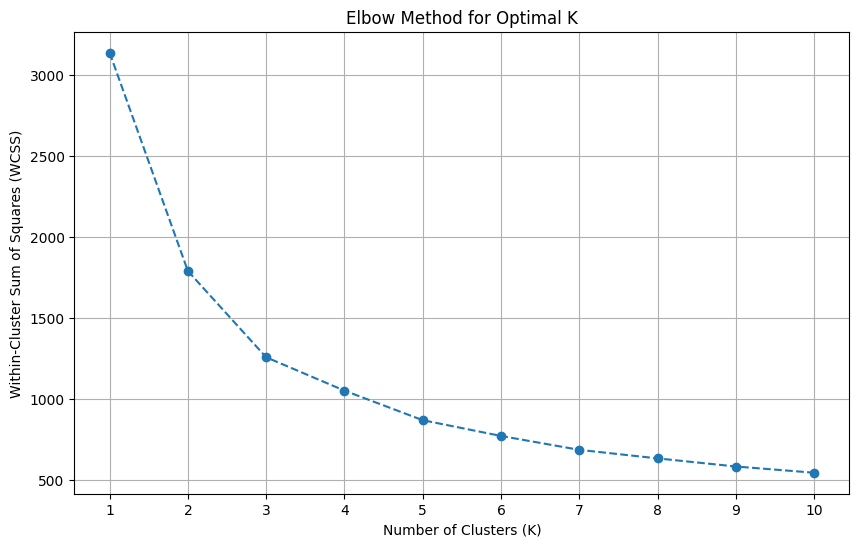

WCSS values for K = 1 to 10 : [3134.9999999999995, 1789.4678147894626, 1258.0639206422388, 1052.6584508982212, 870.4636513451896, 773.3388753499669, 687.7257411721263, 635.090537042164, 585.153301209707, 546.8122185485452]


In [43]:
features_clustering = ['PTS', 'NEW_HEIGHT', 'WEIGHT']
X_clustering = players_90th_percentile_df[features_clustering] # Use the 90th percentile data as in your last cell

scaler_clustering = StandardScaler()
X_scaled_clustering = scaler_clustering.fit_transform(X_clustering)

# Elbow method - list to store sum of squares
ss = []
# Define a range of K values to test
max_k = 10

# Calculate SS for different numbers of clusters
for i in range(1, max_k + 1):
    kmeans = KMeans(n_clusters=i, random_state=42, n_init=10)
    kmeans.fit(X_scaled_clustering)
    ss.append(kmeans.inertia_) # inertia_ is the SS

# Plot the Elbow Method graph
plt.figure(figsize=(10, 6))
plt.plot(range(1, max_k + 1), ss, marker='o', linestyle='--')
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Within-Cluster Sum of Squares (WCSS)')
plt.xticks(range(1, max_k + 1))
plt.grid(True)
plt.show()

print("WCSS values for K = 1 to", max_k, ":", ss)


Cluster Composition (Percentage of each position in each cluster):
POSITION         C         F         G
Cluster                               
0         0.007009  0.212150  0.780841
1         0.110692  0.462893  0.426415
2         0.336609  0.598526  0.064865


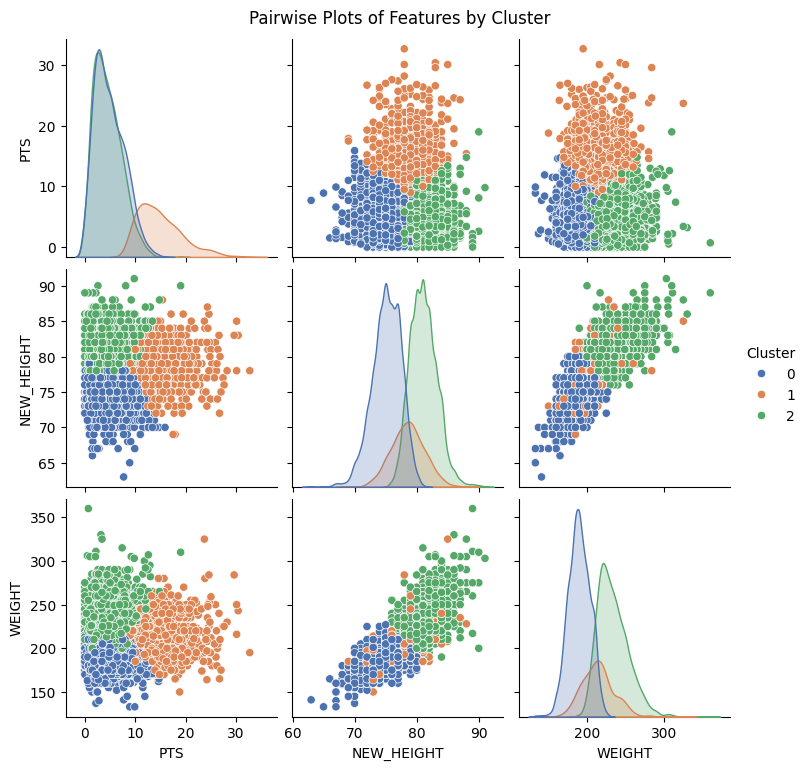

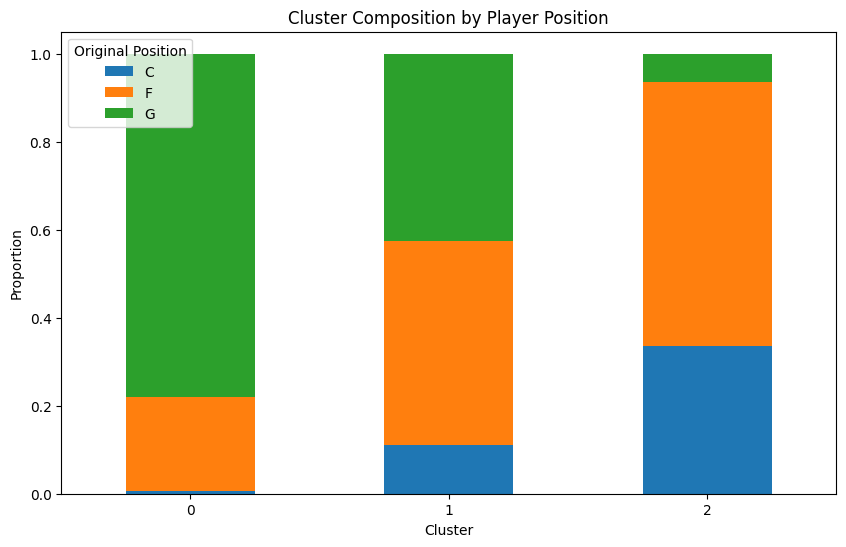

In [44]:
import seaborn as sns

features_clustering = ['PTS', 'NEW_HEIGHT', 'WEIGHT']
X_clustering = bball_df[features_clustering]
scaler_clustering = StandardScaler()
X_scaled_clustering = scaler_clustering.fit_transform(X_clustering)

# Apply K-Means with 3 clusters (although it looked like 2 was more ideal...)
kmeans = KMeans(n_clusters=3, random_state=42, n_init=1000)
bball_df['Cluster'] = kmeans.fit_predict(X_scaled_clustering)

# Analyze the cluster composition by actual position
cluster_composition = bball_df.groupby('Cluster')['POSITION'].value_counts(normalize=True).unstack(fill_value=0)

print("\nCluster Composition (Percentage of each position in each cluster):")
print(cluster_composition)

# Determine the most frequent position in each cluster
cluster_to_position_mapping = cluster_composition.idxmax(axis=1).to_dict()

# Use the dictionary created above to map the new positions obtained from the clusters into the dataframe
bball_df['Predicted_Position_Cluster'] = bball_df['Cluster'].map(cluster_to_position_mapping)

# Pairplots show the relationships between the various
sns.pairplot(bball_df, vars=features_clustering, hue='Cluster', palette='deep')
plt.suptitle('Pairwise Plots of Features by Cluster', y=1.02)
plt.show()

# Creating a bar plot to illustrate how the old positions fall within the new clusters
cluster_composition.plot(kind='bar', stacked=True, figsize=(10, 6))
plt.title('Cluster Composition by Player Position')
plt.xlabel('Cluster')
plt.ylabel('Proportion')
plt.xticks(rotation=0)
plt.legend(title='Original Position')
plt.show()



Cluster Composition (Percentage of each position in each cluster):
POSITION         C         F         G
Cluster                               
0         0.002632  0.071053  0.926316
1         0.118750  0.496875  0.384375
2         0.536232  0.440580  0.023188


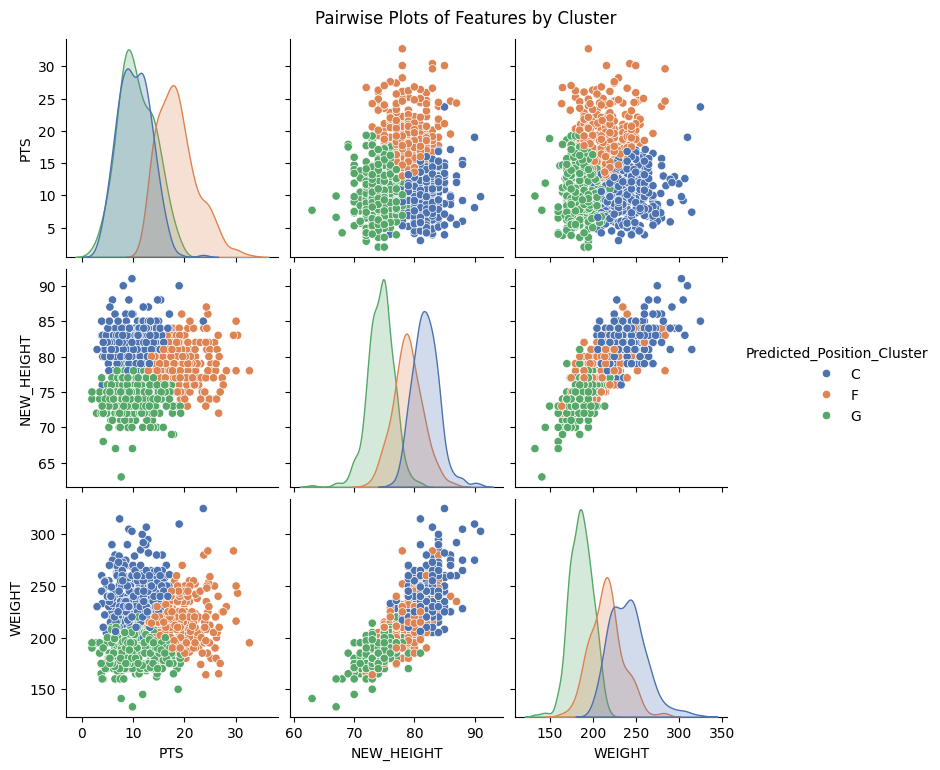

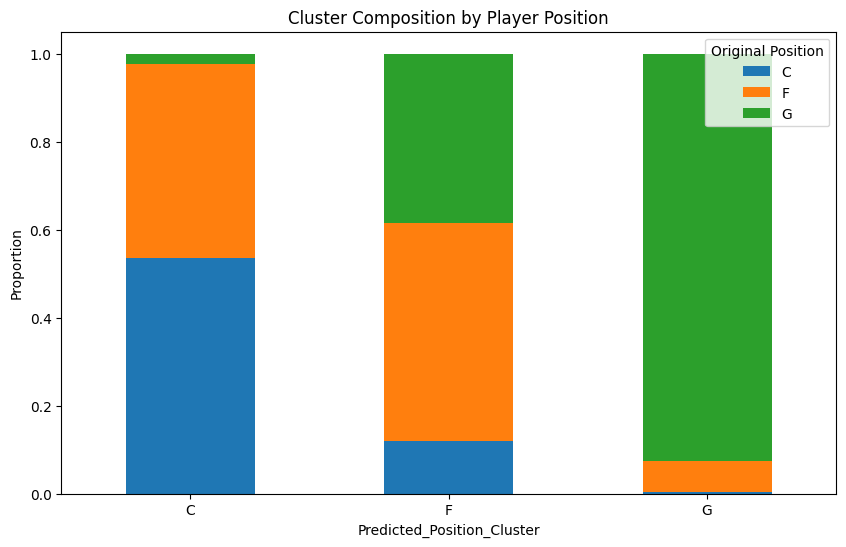

In [45]:
features_clustering = ['PTS', 'NEW_HEIGHT', 'WEIGHT']

# Same exercise as before but with the 90th percentile dataset
X_clustering = players_90th_percentile_df[features_clustering]
scaler_clustering = StandardScaler()
X_scaled_clustering = scaler_clustering.fit_transform(X_clustering)

# Same clustering model as before
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10000)
players_90th_percentile_df['Cluster'] = kmeans.fit_predict(X_scaled_clustering)

# Analyze the cluster composition by actual position
cluster_composition = players_90th_percentile_df.groupby('Cluster')['POSITION'].value_counts(normalize=True).unstack(fill_value=0)

print("\nCluster Composition (Percentage of each position in each cluster):")
print(cluster_composition)

# Determine the most frequent position in each cluster
cluster_to_position_mapping = cluster_composition.idxmax(axis=1).to_dict()

# Use the dictionary created above to map the new positions obtained from the clusters into the dataframe
players_90th_percentile_df['Predicted_Position_Cluster'] = players_90th_percentile_df['Cluster'].map(cluster_to_position_mapping)

# Same pairplots as before
sns.pairplot(players_90th_percentile_df, vars=features_clustering, hue='Predicted_Position_Cluster', palette='deep')
plt.suptitle('Pairwise Plots of Features by Cluster', y=1.02)
plt.show()

# New df grouped by the clusters and displaying only the position and the count (used to add new position label on the below bar chart)
cluster_composition_2 = players_90th_percentile_df.groupby('Predicted_Position_Cluster')['POSITION'].value_counts(normalize=True).unstack(fill_value=0)

cluster_composition_2.plot(kind='bar', stacked=True, figsize=(10, 6))
plt.title('Cluster Composition by Player Position')
plt.xlabel('Predicted_Position_Cluster')
plt.ylabel('Proportion')
plt.xticks(rotation=0)
plt.legend(title='Original Position')
plt.show()

Below is the final comparison between the original position and the two predicted positions.


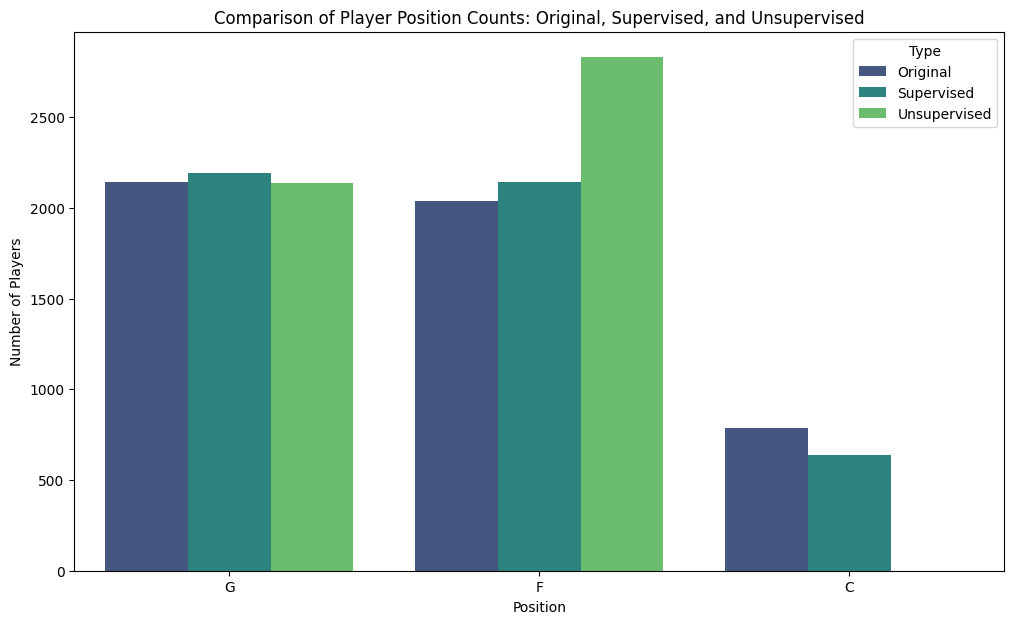

In [46]:
# Predict the position for the entire dataset (for the supervised model)
y_pred_all = best_model_random.predict(New_X)

# Assign the predictions to a new column in the original DataFrame
bball_df['POSITION_Supervised'] = y_pred_all

# Get the counts for each position field (done for each iteration of position)
original_counts = bball_df['POSITION'].value_counts().reset_index()
original_counts.columns = ['Position', 'Count']
original_counts['Type'] = 'Original'

supervised_counts = bball_df['POSITION_Supervised'].value_counts().reset_index()
supervised_counts.columns = ['Position', 'Count']
supervised_counts['Type'] = 'Supervised'

unsupervised_counts = bball_df['Predicted_Position_Cluster'].value_counts().reset_index()
unsupervised_counts.columns = ['Position', 'Count']
unsupervised_counts['Type'] = 'Unsupervised'

# Combine the data for plotting
combined_counts = pd.concat([original_counts, supervised_counts, unsupervised_counts])

# Create the grouped bar plot
plt.figure(figsize=(12, 7))
sns.barplot(data=combined_counts, x='Position', y='Count', hue='Type', palette='viridis')
plt.title('Comparison of Player Position Counts: Original, Supervised, and Unsupervised')
plt.xlabel('Position')
plt.ylabel('Number of Players')
plt.show()

Same chart as above but for the 90th percentile data.

Side bar: 90th percentile dataset was not run through the supervised model, this is done below before the final comparison.

In [47]:
# Obtaining the X & y to be used in the training and testing
New_features = ['PTS', 'REB', 'AST','NEW_HEIGHT','WEIGHT']
New_X = players_90th_percentile_df[New_features]
y = players_90th_percentile_df[target]

X_train, X_test, y_train, y_test = train_test_split(New_X, y, test_size=0.2, random_state=42)

lr = LogisticRegression(random_state=42)
rf = RandomForestClassifier(random_state=42)
svc = SVC(probability=False, random_state=42)

# It was found that 'hard' voting yielded slightly more accurate answers
vc = VotingClassifier(estimators=[('lr', lr), ('rf', rf), ('svc', svc)], voting='hard')

# Create a pipeline
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('voting', vc)
])

pipeline.fit(X_train, y_train)
y_pred_train = pipeline.predict(X_train)
accuracy_train = accuracy_score(y_train, y_pred_train)
print(f'Accuracy on Training Set: {accuracy_train:.4f}')

y_pred_test = pipeline.predict(X_test)

accuracy_test = accuracy_score(y_test, y_pred_test)
print(f'Accuracy on Test Set: {accuracy_test:.4f}')

Accuracy on Training Set: 0.8995
Accuracy on Test Set: 0.8373


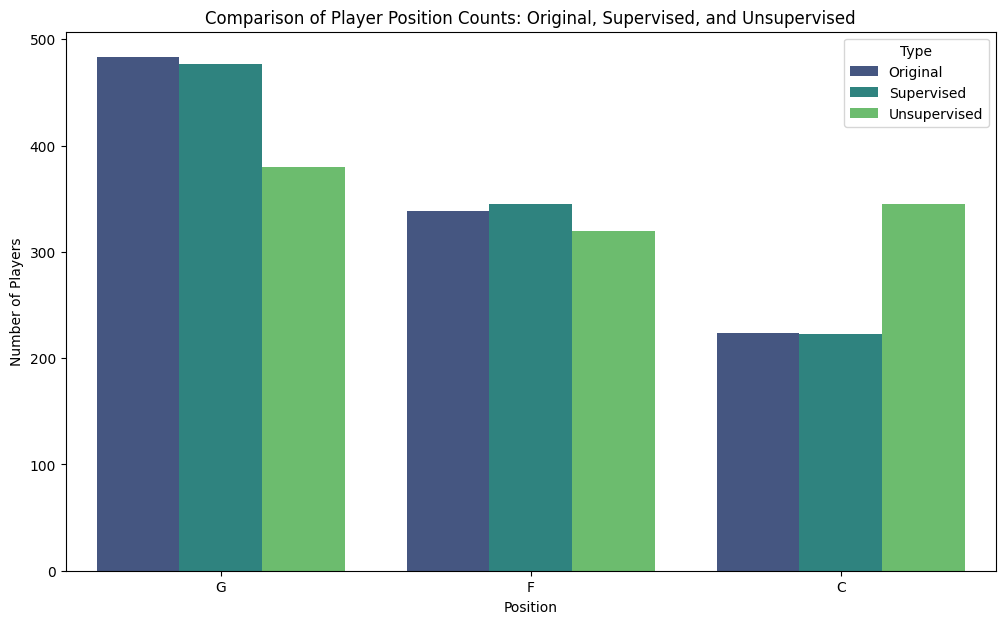

In [48]:
# Predict the position for the entire dataset (for the supervised model)
y_pred_all = pipeline.predict(New_X)

# Assign the predictions to a new column in the original DataFrame
players_90th_percentile_df['POSITION_Supervised'] = y_pred_all

# Get the counts for each position field (done for each iteration of position)
original_counts = players_90th_percentile_df['POSITION'].value_counts().reset_index()
original_counts.columns = ['Position', 'Count']
original_counts['Type'] = 'Original'

supervised_counts = players_90th_percentile_df['POSITION_Supervised'].value_counts().reset_index()
supervised_counts.columns = ['Position', 'Count']
supervised_counts['Type'] = 'Supervised'

unsupervised_counts = players_90th_percentile_df['Predicted_Position_Cluster'].value_counts().reset_index()
unsupervised_counts.columns = ['Position', 'Count']
unsupervised_counts['Type'] = 'Unsupervised'

# Combine the data for plotting
combined_counts = pd.concat([original_counts, supervised_counts, unsupervised_counts])

# Create the grouped bar plot
plt.figure(figsize=(12, 7))
sns.barplot(data=combined_counts, x='Position', y='Count', hue='Type', palette='viridis')
plt.title('Comparison of Player Position Counts: Original, Supervised, and Unsupervised')
plt.xlabel('Position')
plt.ylabel('Number of Players')
plt.show()